In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.spatial.distance import cdist
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant

In [2]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [3]:
def rdp(trajectory, epsilon, metric='euclidean', return_indices=False):
    """
    Simplify an n-dimensional trajectory using the Ramer-Douglas-Peucker algorithm.

    Parameters
    ----------
    trajectory : numpy.ndarray
        A (timepoints x features) matrix representing the curve to simplify.
    epsilon : float
        Maximum allowed distance from a point to the simplified curve. Points
        farther than epsilon from the line segment connecting their neighbors
        are retained.
    metric : str or callable
        Distance metric used when computing point-to-segment distances.
        Accepts any distance name supported by scipy.spatial.distance.cdist
        (e.g. 'euclidean', 'cosine', 'correlation') or a callable with
        signature f(u, v) -> float.
    return_indices : bool, default False
        If True, return a tuple (simplified_trajectory, indices) where
        indices is a 1D array of the retained point indices into the original
        trajectory. If False, return only the simplified trajectory.

    Returns
    -------
    numpy.ndarray or tuple
        The simplified trajectory, or (simplified_trajectory, indices) when
        return_indices is True.
    """
    def _dist(points, start, end):
        """
        Compute the distance from each point in `points` to the line segment
        defined by `start` and `end`.

        The perpendicular foot is clamped to the segment so that points past
        either endpoint are measured to the nearest endpoint instead.
        """
        segment = end - start
        seg_len_sq = np.dot(segment, segment)

        if seg_len_sq == 0:
            # Degenerate segment: start == end; distance is point-to-point.
            if callable(metric):
                return np.array([metric(p, start) for p in points])
            return cdist(points, start[np.newaxis], metric=metric).ravel()

        # Scalar projection of each point onto the segment, clamped to [0, 1].
        t = np.clip(
            np.dot(points - start, segment) / seg_len_sq,
            0.0, 1.0
        )                                           # shape (n,)
        projections = start + t[:, np.newaxis] * segment   # shape (n, d)

        if callable(metric):
            return np.array([metric(p, proj) for p, proj in zip(points, projections)])
        # cdist expects 2-D arrays.
        return cdist(points, projections, metric=metric).diagonal()

    def _rdp_indices(indices):
        """
        Recursively collect the indices of points to keep.
        Works on a view into the global `trajectory` array.
        """
        if len(indices) <= 2:
            return list(indices)

        start = trajectory[indices[0]]
        end   = trajectory[indices[-1]]
        inner = indices[1:-1]

        dists = _dist(trajectory[inner], start, end)
        max_idx = np.argmax(dists)
        max_dist = dists[max_idx]

        if max_dist > epsilon:
            pivot = max_idx + 1   # position within `indices`
            left  = _rdp_indices(indices[:pivot + 1])
            right = _rdp_indices(indices[pivot:])
            # Merge, avoiding the duplicate at the pivot.
            return left[:-1] + right
        else:
            return [indices[0], indices[-1]]

    trajectory = np.asarray(trajectory)
    kept = _rdp_indices(list(range(len(trajectory))))
    kept = np.array(kept)

    simplified = trajectory[kept]
    return (simplified, kept) if return_indices else simplified

In [4]:
EPSILONS = np.round(np.arange(0, 2.01, 0.1), 2)  # 21 values: 0.0, 0.1, ..., 2.0
n_eps = len(EPSILONS)

counts = {
    'atlep1': np.zeros((len(participants), n_eps), dtype=int),
    'delayed': np.zeros((len(participants), n_eps), dtype=int),
}

for i, p in enumerate(tqdm(participants, leave=False)):
    traj_atl = p.trajectories['atlep1']
    traj_del = p.trajectories['delayed']
    for j, eps in enumerate(EPSILONS):
        counts['atlep1'][i, j] = len(rdp(traj_atl, epsilon=eps, metric='correlation'))
        counts['delayed'][i, j] = len(rdp(traj_del, epsilon=eps, metric='correlation'))

  0%|          | 0/57 [00:00<?, ?it/s]

In [15]:
# For each epsilon, check whether any participant (either trajectory) still
# has more than 2 retained points. The plot should only cover the range where
# at least one participant has not yet fully collapsed to the two endpoints.
combined = np.concatenate([counts['atlep1'], counts['delayed']], axis=0)  # (114, n_eps)
any_gt2 = np.any(combined > 2, axis=0)  # True at each epsilon where at least 1 participant has >2 points

# Last epsilon index where any participant still has >2 retained points
max_eps_idx = int(np.where(any_gt2)[0][-1])

# Trim in-place so the plot cell picks up the updated variables automatically
EPSILONS = EPSILONS[:max_eps_idx + 1]
n_eps = len(EPSILONS)
counts = {k: v[:, :max_eps_idx + 1] for k, v in counts.items()}

print(f"Plotting epsilons 0.0 to {EPSILONS[-1]:.1f}  ({n_eps} values)")

Plotting epsilons 0.0 to 1.4  (15 values)


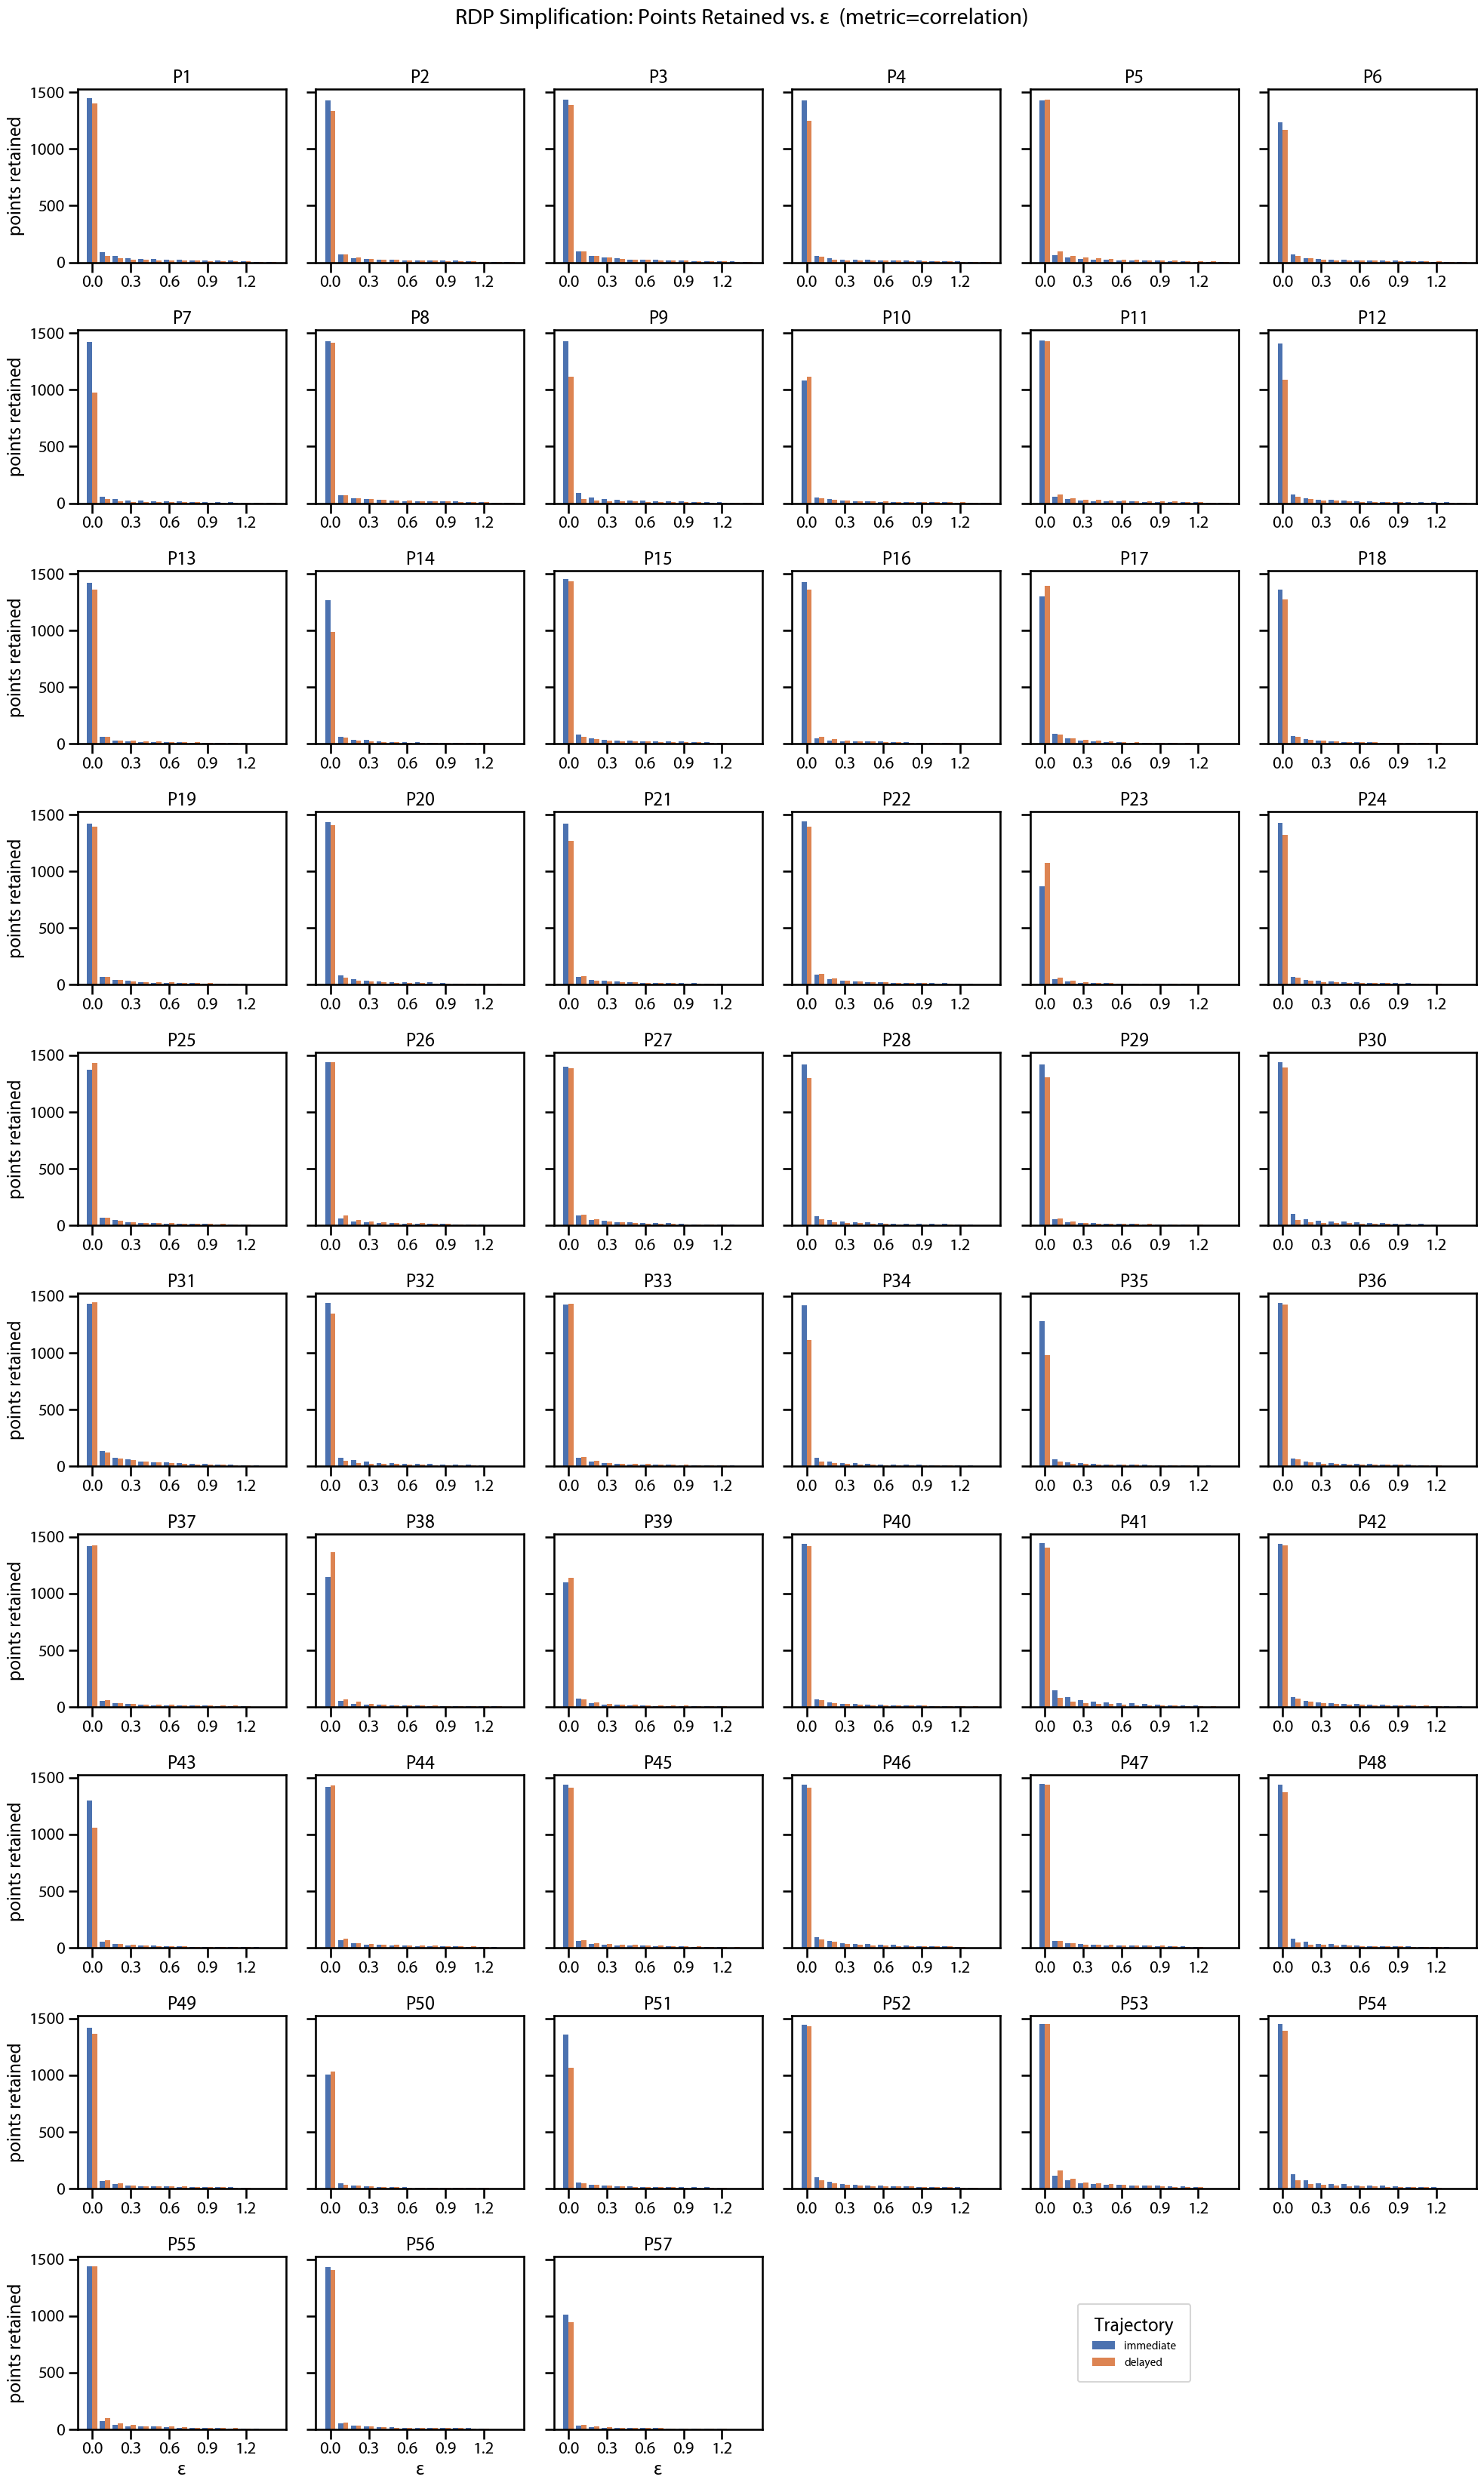

In [28]:
with sns.plotting_context('talk'):
    NROWS, NCOLS = 10, 6
    fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 33), sharey=True)

    x = np.arange(n_eps)
    bar_w = 0.4
    colors = {'atlep1': '#4C72B0', 'delayed': '#DD8452'}

    for i, p in enumerate(participants):
        row, col = divmod(i, NCOLS)
        ax = axes[row, col]

        ax.bar(x - bar_w / 2, counts['atlep1'][i], width=bar_w,
               color=colors['atlep1'], label='atlep1')
        ax.bar(x + bar_w / 2, counts['delayed'][i], width=bar_w,
               color=colors['delayed'], label='delayed')

        ax.set_title(f'P{p.sub_n}')
        # Show ~4-5 ticks regardless of how many epsilons remain after trimming
        tick_step = max(1, n_eps // 5)
        ax.set_xticks(x[::tick_step])
        ax.set_xticklabels(EPSILONS[::tick_step])
        ax.tick_params(axis='y')
        ax.set_xlabel('ε')
        ax.set_ylabel('points retained')
        
        if i % 6:
            ax.set_ylabel('')
        if i < 54:
            ax.set_xlabel('')

    # Hide all 3 unused subplots (indices 57–59 → row 9, cols 3–5)
    for idx in range(len(participants), NROWS * NCOLS):
        row, col = divmod(idx, NCOLS)
        axes[row, col].set_visible(False)

    # Re-enable the middle unused cell (index 58 → row 9, col 4) to host the legend
    legend_ax = axes[9, 4]
    legend_ax.set_visible(True)
    legend_ax.axis('off')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    legend_ax.legend(handles, ['immediate', 'delayed'], loc='center', fontsize=11,
                     title='Trajectory', frameon=True,
                     handlelength=2, borderpad=1.2)

    fig.suptitle('RDP Simplification: Points Retained vs. ε  (metric=correlation)', y=1)
    plt.tight_layout()
    plt.show()

array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 , 0.055, 0.06 , 0.065, 0.07 , 0.075, 0.08 , 0.085,
       0.09 , 0.095, 0.1  ])

In [31]:
EPSILONS = np.round(np.linspace(0, 0.1, 21), 2)
n_eps = len(EPSILONS)

counts = {
    'atlep1': np.zeros((len(participants), n_eps), dtype=int),
    'delayed': np.zeros((len(participants), n_eps), dtype=int),
}

for i, p in enumerate(tqdm(participants, leave=False)):
    traj_atl = p.trajectories['atlep1']
    traj_del = p.trajectories['delayed']
    for j, eps in enumerate(EPSILONS):
        counts['atlep1'][i, j] = len(rdp(traj_atl, epsilon=eps, metric='correlation'))
        counts['delayed'][i, j] = len(rdp(traj_del, epsilon=eps, metric='correlation'))

  0%|          | 0/57 [00:00<?, ?it/s]

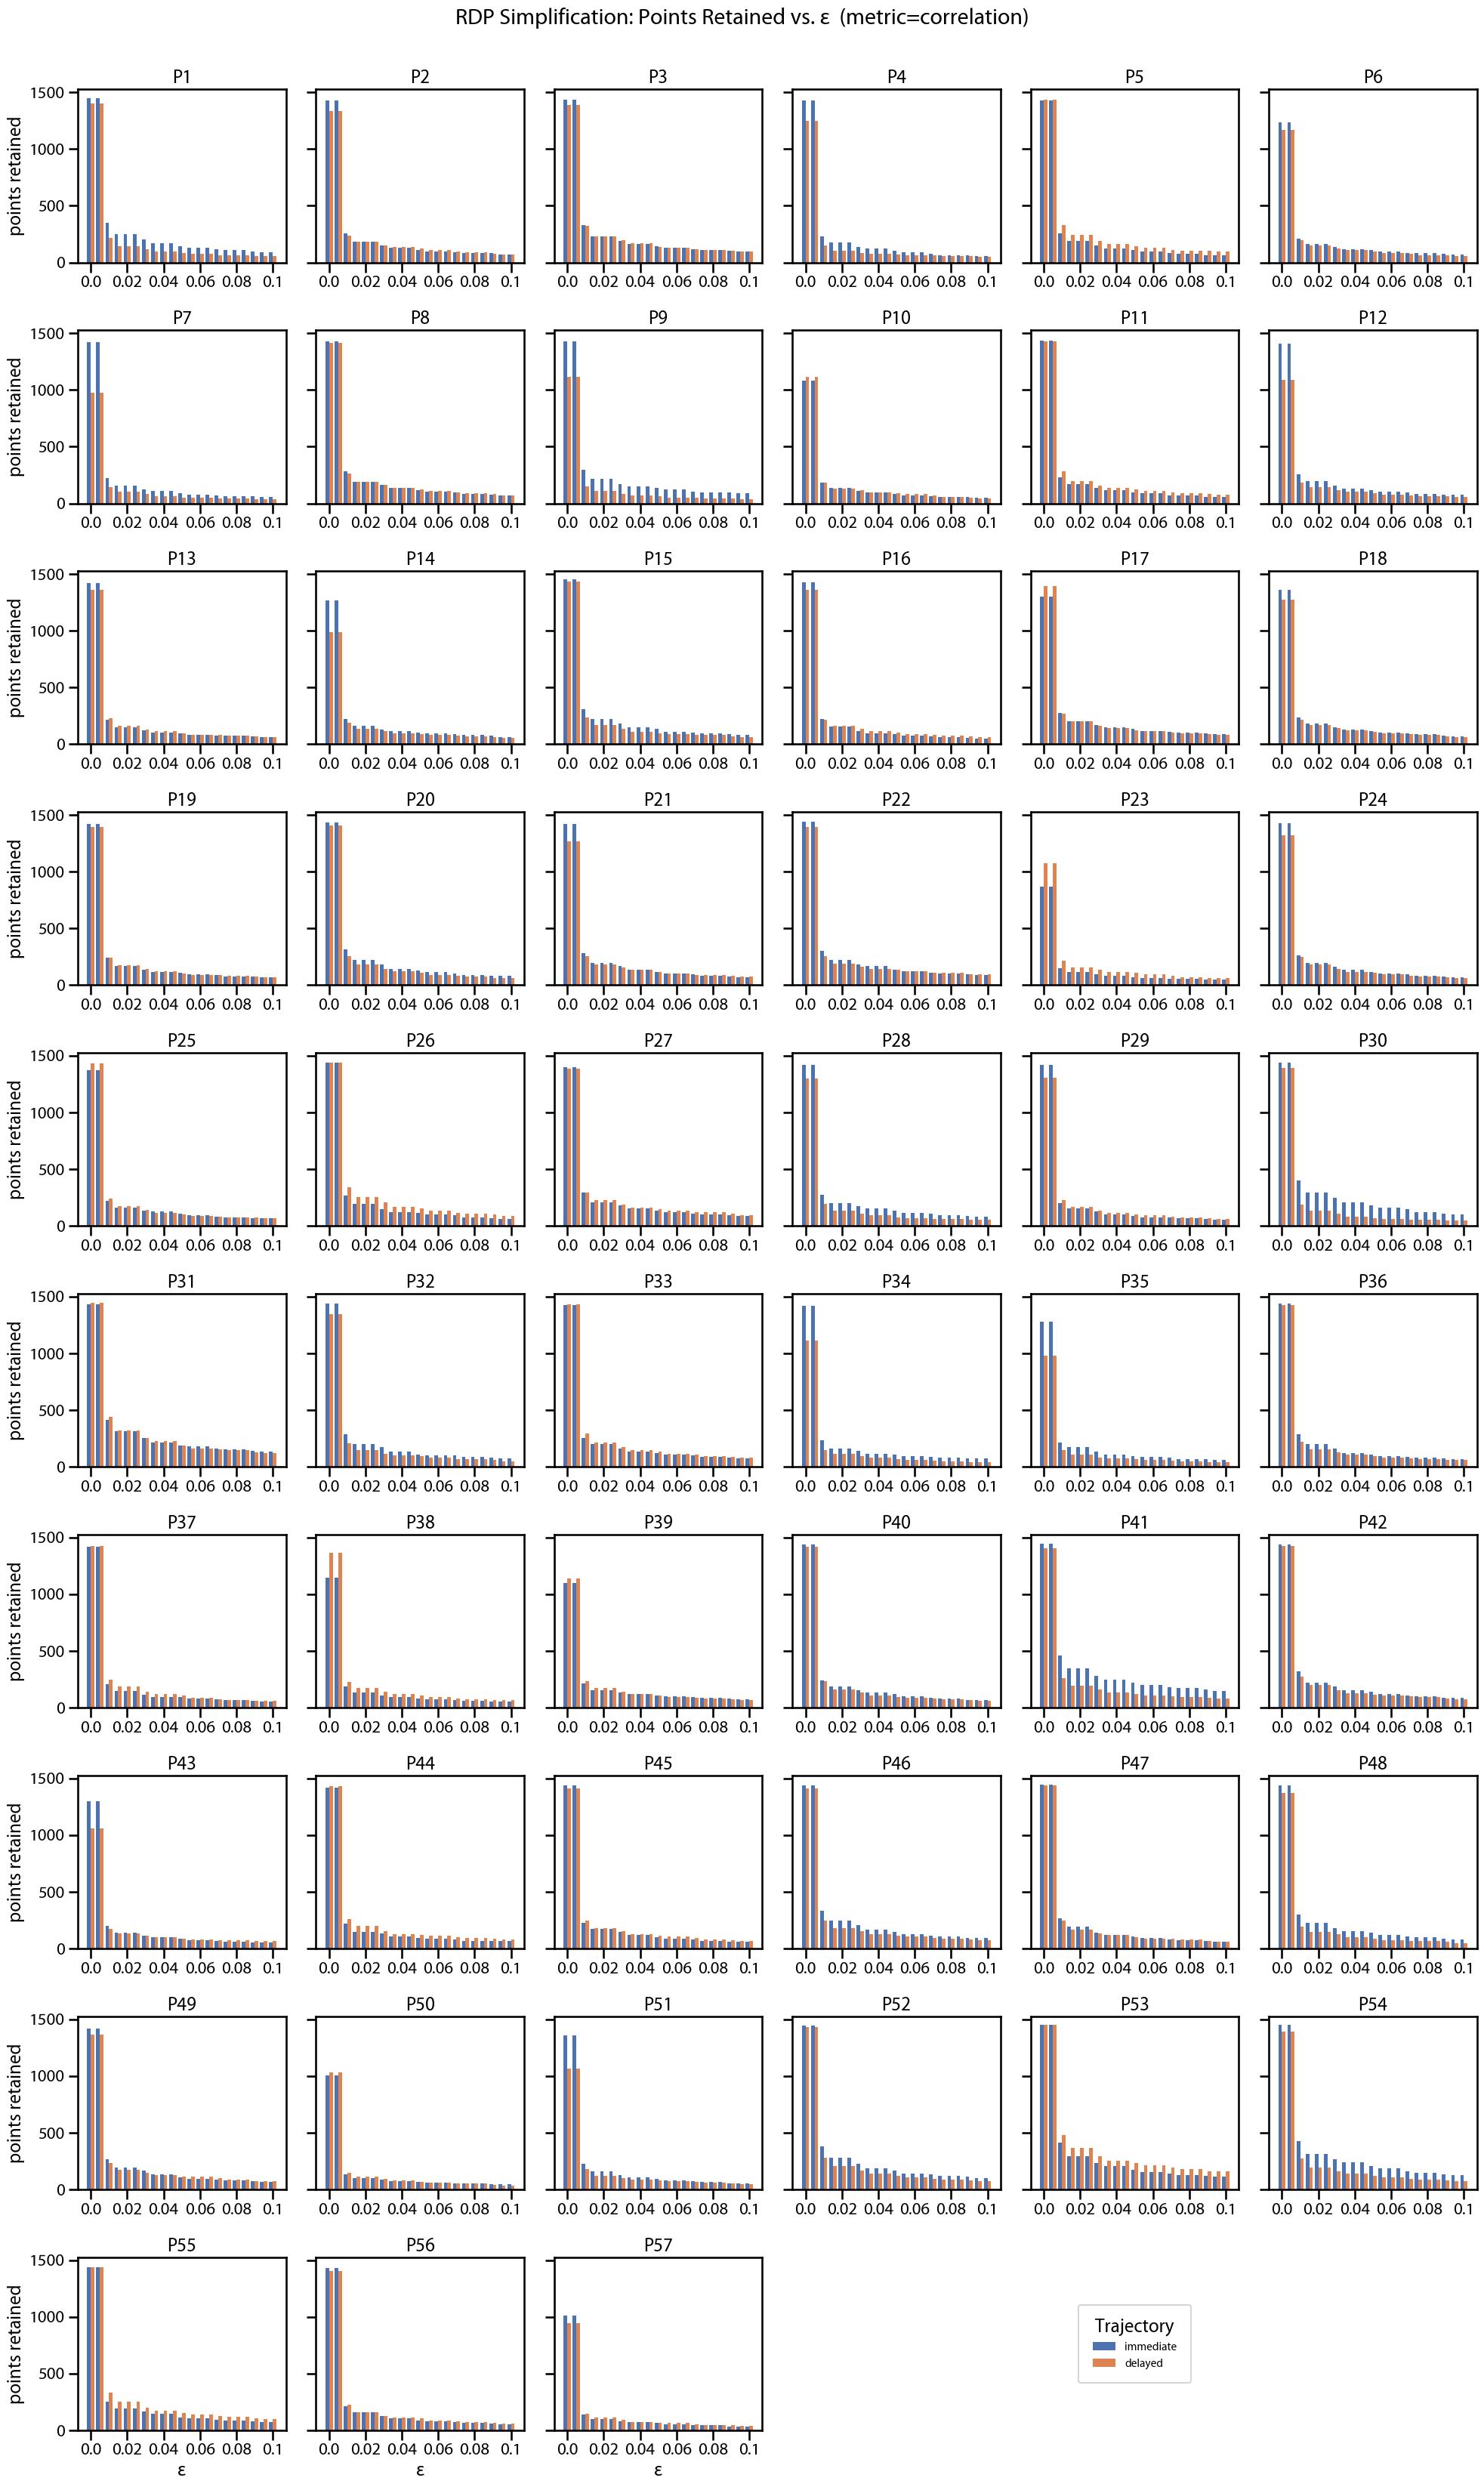

In [32]:
with sns.plotting_context('talk'):
    NROWS, NCOLS = 10, 6
    fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 33), sharey=True)

    x = np.arange(n_eps)
    bar_w = 0.4
    colors = {'atlep1': '#4C72B0', 'delayed': '#DD8452'}

    for i, p in enumerate(participants):
        row, col = divmod(i, NCOLS)
        ax = axes[row, col]

        ax.bar(x - bar_w / 2, counts['atlep1'][i], width=bar_w,
               color=colors['atlep1'], label='atlep1')
        ax.bar(x + bar_w / 2, counts['delayed'][i], width=bar_w,
               color=colors['delayed'], label='delayed')

        ax.set_title(f'P{p.sub_n}')
        # Show ~4-5 ticks regardless of how many epsilons remain after trimming
        tick_step = max(1, n_eps // 5)
        ax.set_xticks(x[::tick_step])
        ax.set_xticklabels(EPSILONS[::tick_step])
        ax.tick_params(axis='y')
        ax.set_xlabel('ε')
        ax.set_ylabel('points retained')
        
        if i % 6:
            ax.set_ylabel('')
        if i < 54:
            ax.set_xlabel('')

    # Hide all 3 unused subplots (indices 57–59 → row 9, cols 3–5)
    for idx in range(len(participants), NROWS * NCOLS):
        row, col = divmod(idx, NCOLS)
        axes[row, col].set_visible(False)

    # Re-enable the middle unused cell (index 58 → row 9, col 4) to host the legend
    legend_ax = axes[9, 4]
    legend_ax.set_visible(True)
    legend_ax.axis('off')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    legend_ax.legend(handles, ['immediate', 'delayed'], loc='center', fontsize=11,
                     title='Trajectory', frameon=True,
                     handlelength=2, borderpad=1.2)

    fig.suptitle('RDP Simplification: Points Retained vs. ε  (metric=correlation)', y=1)
    plt.tight_layout()
    plt.show()

In [27]:
labels

['atlep1', 'delayed']